# Powergrid

## Loading dataset

In [1]:
import networkx as nx

G = nx.Graph()
with open('./data/raw/powergrid.txt') as f:
    for line in f:
        u,v = map(int, line.split())
        G.add_edge(u,v)

In [2]:
degrees = [d for _, d in G.degree()]

## Network analysis 

In [3]:
from collections import Counter

degree_count = Counter(degrees)
N = len(degrees)

k = list(degree_count.keys())
pk = [count / N for count in degree_count.values()]

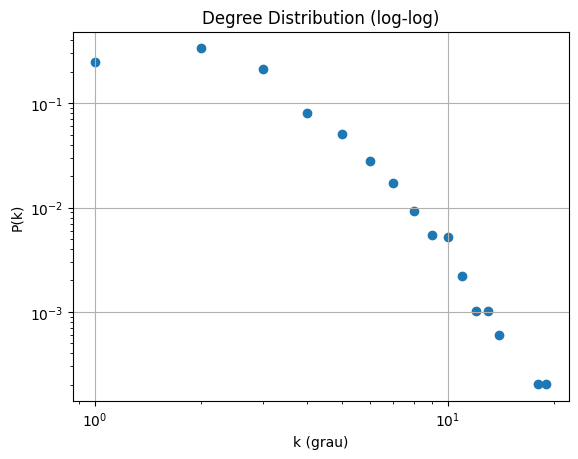

In [4]:
import matplotlib.pyplot as plt

plt.scatter(k, pk)
plt.xscale('log')
plt.yscale('log')

plt.xlabel("k (grau)")
plt.ylabel("P(k)")
plt.title("Degree Distribution (log-log)")

plt.grid(True)
plt.show()

## Complexity

$$
\frac{\frac{1}{N}\sum_{i=1}^{N} k_i^2}{\frac{1}{N}\sum_{i=1}^{N} k_i}
$$

In [5]:
import numpy as np

def degree_moment(degrees, n):
    degrees = np.array(degrees)
    return np.mean(degrees ** n)

In [6]:
degrees = [d for _, d in G.degree()]

k_1 = degree_moment(degrees,1)
k_2 = degree_moment(degrees,2)

print(f'{(k_2/k_1):.2f}')

3.87
